# Laboratorio 3: Redes neuronales convolucionales

- Mathew Cordero 22982
- Pedro Guzmán 22111

In [ ]:

# Esto solo en google colab
# # Instalaciones necesarias en colab e importaciones en colab

# from google.colab import drive
# drive.mount('/content/drive')
# !apt-get install unrar -y
# import os

# rar_path = "/content/drive/MyDrive/MMNIST/test.rar"
# output_dir = os.path.dirname(rar_path)  # Mismo directorio

# !unrar x -o+ "{rar_path}" "{output_dir}"




In [12]:

# Esto solo en google colab
# # Instalaciones necesarias en colab e importaciones en colab

# from google.colab import drive
# drive.mount('/content/drive')
# !apt-get install unrar -y
# import os

# rar_path = "/content/drive/MyDrive/MMNIST/train.rar"
# output_dir = os.path.dirname(rar_path)  # Mismo directorio

# !unrar x -o+ "{rar_path}" "{output_dir}"




Se truncaron las últimas líneas 5000 del resultado de transmisión.
Extracting  /content/drive/MyDrive/MMNIST/train/m4/6139.1.png             98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/6139.7.png             98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.0.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.1.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.2.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.3.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.4.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.5.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.6.png              98%  OK 
Extracting  /content/drive/MyDrive/MMNIST/train/m4/614.7.png              98%  OK 
Extracting  /

## Análisis exploratorio

Primero empezaremos haciendo un análisis exploratorio sobre el conjunto de imágenes, obtendremos información de sus dimensiones, cuántas hay, que formatos tienen, etc.

In [9]:
import os
#import cv2
import pandas as pd
from PIL import Image

def analyze_dataset(base_path):
    data = []

    for subfolder in sorted(os.listdir(base_path)):
        subfolder_path = os.path.join(base_path, subfolder)

        if not os.path.isdir(subfolder_path):
            continue

        for file in os.listdir(subfolder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subfolder_path, file)
                size_kb = os.path.getsize(img_path) / 1024
                with Image.open(img_path) as img:
                    data.append({
                        "Carpeta": subfolder,
                        "Nombre": file,
                        "Formato": img.format,
                        "Ancho": img.width,
                        "Alto": img.height,
                        "Tamaño (KB)": size_kb
                    })
    return pd.DataFrame(data)


In [10]:
base_path = "/content/drive/MyDrive/MMNIST/test" # aqui agregar el path que necesitas yo como lo hago en colab asi lo pusimos
df = analyze_dataset(base_path)
df.head()  # Muestra las primeras filas


,Carpeta,Nombre,Formato,Ancho,Alto,Tamaño (KB)
0,m0,443.9.png,PNG,28,28,0.983398
1,m0,444.4.png,PNG,28,28,2.151367
2,m0,444.1.png,PNG,28,28,0.857422
3,m0,444.0.png,PNG,28,28,0.920898
4,m0,444.2.png,PNG,28,28,1.006836


In [14]:
print("Tamaño del DataFrame:", df.shape)  # Muestra (filas, columnas)


Tamaño del DataFrame: (50000, 6)


In [15]:
train_path = "/content/drive/MyDrive/MMNIST/train"
df_train = analyze_dataset(train_path)

print(f"🔹 Total de imágenes en TRAIN: {len(df_train)}")
df_train.groupby("Carpeta").size()

🔹 Total de imágenes en TRAIN: 300000


,0
Carpeta,
m0,60000
m1,60000
m2,60000
m3,60000
m4,60000


In [16]:
df_test = df

Ahora que generamos los datasets, los guardamos como csv

In [17]:
df_test.to_csv('test_images.csv', index=False)
df_train.to_csv('train_images.csv', index=False)

Ahora obtenemos un resumen inicial sobre las característcas iniciales.

In [18]:
df_test.describe()

,Ancho,Alto,Tamaño (KB)
count,50000.0,50000.0,50000.000000
mean,28.0,28.0,1.444386
std,0.0,0.0,0.387236
min,28.0,28.0,0.275391
25%,28.0,28.0,1.105469
50%,28.0,28.0,1.473633
75%,28.0,28.0,1.771484
max,28.0,28.0,2.318359


Todas las imágenes en el conjunto de prueba tienen las mismas dimensiones, sin embargo su tamaño en kb cambia, esto sugiere que tal vez las imágenes más pesadas tienen más colores y formas más complejas. Ahora veremos una pequeña muestra de las imágenes.

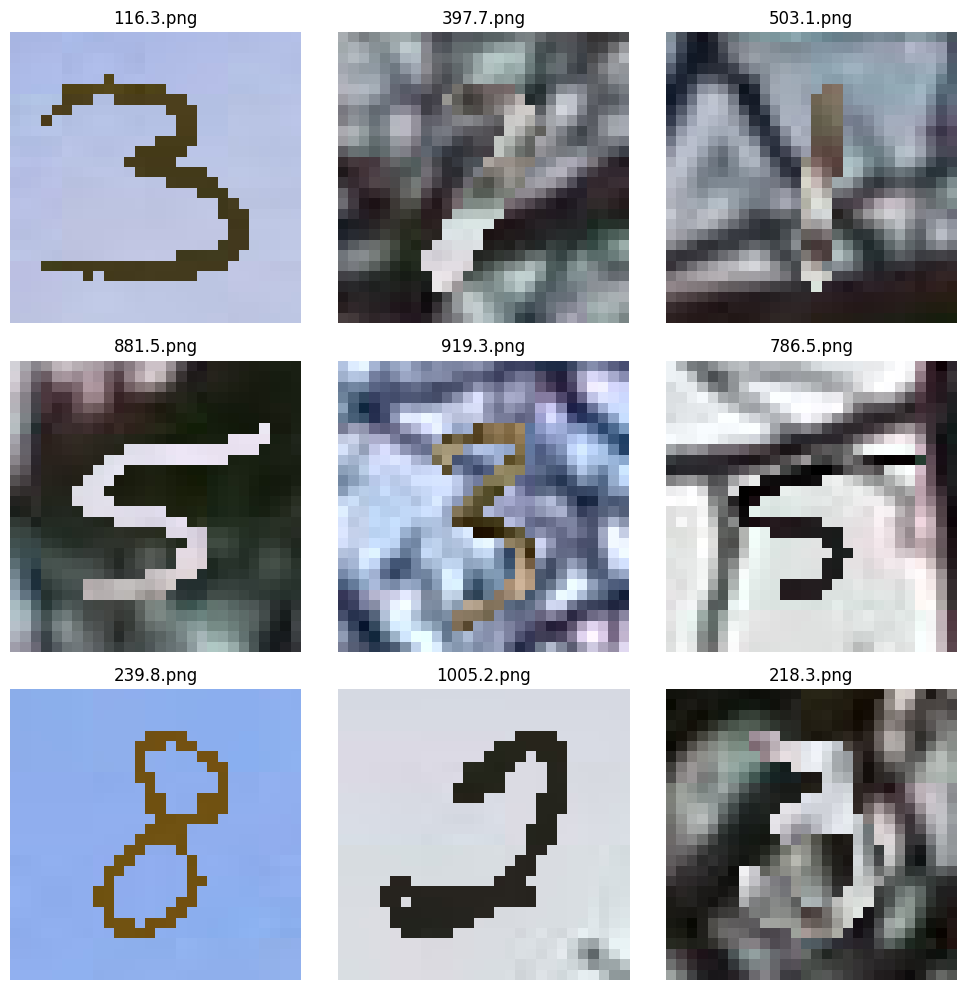

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

folder = base_path + "/m0"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()


Hay imágenes con más resolución que otras, esto confirma la razón de porque no todas tienen el mismo tamaño. Ahora vamos con las de train

In [21]:
df_train.describe()

,Ancho,Alto,Tamaño (KB)
count,300000.0,300000.0,300000.000000
mean,28.0,28.0,1.443726
std,0.0,0.0,0.387686
min,28.0,28.0,0.250000
25%,28.0,28.0,1.104492
50%,28.0,28.0,1.473633
75%,28.0,28.0,1.769531
max,28.0,28.0,2.301758


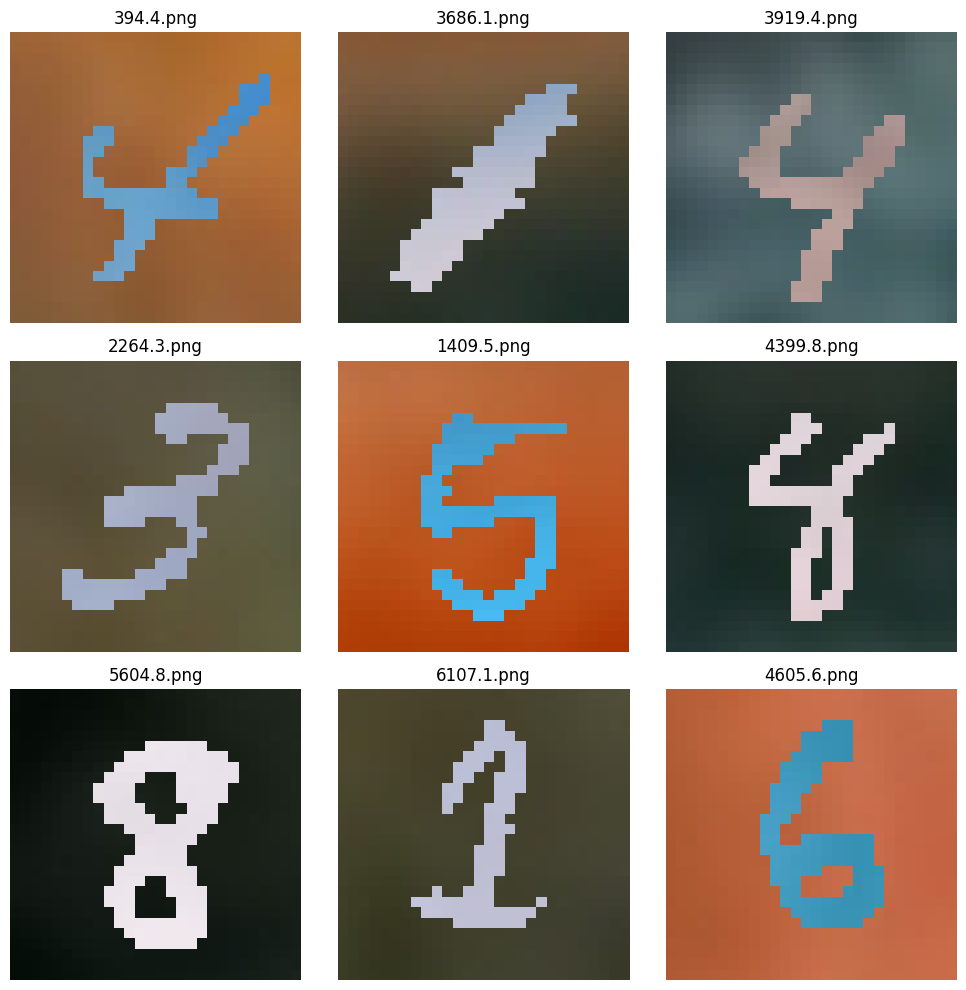

In [24]:
folder = train_path + "/m1"
files = os.listdir(folder)
files = [f for f in files if f.endswith(".png")]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    file = random.choice(files)
    img = mpimg.imread(os.path.join(folder, file))
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocesamiento de Imagenes

Vimos que algunas imágenes tienen una ligera rotación por lo que a cada una le aplicaremos también una pequeña rotación de 15 grados, otra cosas que haremos es convertir todo a escala de grises y normalizar.

In [29]:

# Esto solo sirve en google colab
# import os
# import shutil
# from tqdm import tqdm

# def copy_with_progress(src_dir, dst_dir):
#     os.makedirs(dst_dir, exist_ok=True)

#     # Contar cuántos archivos hay
#     all_files = []
#     for root, _, files in os.walk(src_dir):
#         for f in files:
#             src_file = os.path.join(root, f)
#             rel_path = os.path.relpath(src_file, src_dir)
#             dst_file = os.path.join(dst_dir, rel_path)
#             all_files.append((src_file, dst_file))

#     for src_file, dst_file in tqdm(all_files, desc=f"Copiando {src_dir}", unit="archivo"):
#         os.makedirs(os.path.dirname(dst_file), exist_ok=True)
#         shutil.copy2(src_file, dst_file)

# # 🔄 Usar
# copy_with_progress("/content/drive/MyDrive/MMNIST/test",  "/content/test")
# copy_with_progress("/content/drive/MyDrive/MMNIST/train", "/content/train")


Copiando /content/drive/MyDrive/MMNIST/train: 100%|██████████| 300000/300000 [25:59<00:00, 192.43archivo/s]


In [30]:
import os
import tensorflow as tf
from tqdm import tqdm

def process_dataset_tf(input_path, output_path):
    os.makedirs(output_path, exist_ok=True)

    for folder in os.listdir(input_path):  # m0, m1, m2, ...
        input_folder = os.path.join(input_path, folder)
        if not os.path.isdir(input_folder):
            continue

        for file in tqdm(os.listdir(input_folder), desc=f"Procesando {folder}"):
            if not file.endswith(".png"):
                continue

            try:
                class_label = file.split(".")[1]  # "31.0.png" -> "0"
            except IndexError:
                continue

            label_folder = os.path.join(output_path, class_label)
            os.makedirs(label_folder, exist_ok=True)

            # Leer imagen como tensor
            img_path = os.path.join(input_folder, file)
            try:
                image_raw = tf.io.read_file(img_path)
                image_tensor = tf.image.decode_png(image_raw, channels=3)

                # Convertir a escala de grises y redimensionar (en GPU si está disponible)
                gray = tf.image.rgb_to_grayscale(image_tensor)
                resized = tf.image.resize(gray, [28, 28])

                # Convertir tensor a PNG nuevamente
                resized_uint8 = tf.cast(resized, tf.uint8)
                encoded = tf.io.encode_png(resized_uint8)

                # Guardar imagen
                out_path = os.path.join(label_folder, file)
                tf.io.write_file(out_path, encoded)
            except Exception as e:
                print(f"❌ Error al procesar {file}: {e}")

# 📂 Paths
train_path = "/content/train"
test_path  = "/content/test"

output_train = "images/train_gray_sorted_tf"
output_test  = "images/test_gray_sorted_tf"

# 🚀 Ejecutar
process_dataset_tf(train_path, output_train)
process_dataset_tf(test_path, output_test)

print("✅ Procesamiento con TensorFlow terminado.")


Procesando m0: 100%|██████████| 10000/10000 [00:48<00:00, 207.00it/s]

✅ Procesamiento con TensorFlow terminado.


AHora los cargamos en tensorflow, ya que nos servira para entrenar los modelos

In [41]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "images/train_gray_sorted_tf",
    image_size=(28,28),
    color_mode='grayscale',
    batch_size=512,
    label_mode='int'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "images/test_gray_sorted_tf",
    image_size=(28,28),
    color_mode='grayscale',
    batch_size=512,
    label_mode='int'
)


Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


Ahora normalizaremos a pixeles, esto sirve para poner en rangos de 0s y 1s . Este un ejemplo de como seria

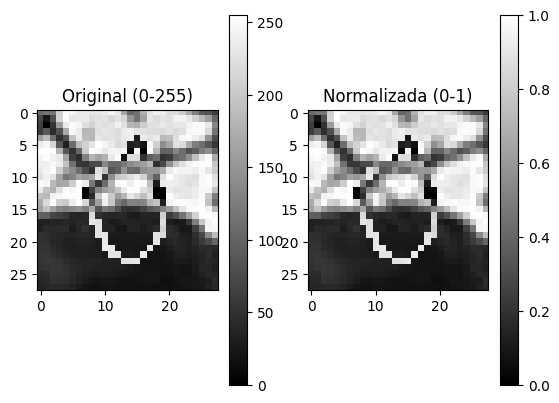

In [42]:
import tensorflow as tf
import matplotlib.pyplot as plt


img_path = "/content/images/train_gray_sorted_tf/0/31.0.png"  # pon aquí una ruta válida en tu disco


image_raw = tf.io.read_file(img_path)
image = tf.image.decode_png(image_raw, channels=1)  # escala de grises


plt.subplot(1, 2, 1)
plt.title("Original (0-255)")
plt.imshow(tf.squeeze(image), cmap='gray')
plt.colorbar()


normalization_layer = tf.keras.layers.Rescaling(1./255)
image_norm = normalization_layer(image)


plt.subplot(1, 2, 2)
plt.title("Normalizada (0-1)")
plt.imshow(tf.squeeze(image_norm), cmap='gray')
plt.colorbar()

plt.show()


Ahora si normalizamos todas

In [43]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Y aqui dividimos en validacion y testeo

In [54]:
# Cantidad total de batches en test_ds
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

# 20% para validación, 80% para test
val_batches = int(test_batches * 0.2)
test_batches_final = test_batches - val_batches

# Crear validación y test final con take y skip
val_ds = test_ds.take(val_batches)
test_ds_final = test_ds.skip(val_batches)


# *Modelos*

Lo que vamos a hacer antes de todo esto, es ejecutarlo en coolab ya que no tenemos GPU y nos permite usar la memoria extendida. Asi que al cambiar el entorno de ejecucion damos esto

In [55]:
import tensorflow as tf

# Verificar si hay GPU disponible
gpu_disponible = tf.config.list_physical_devices('GPU')
print("¿GPU disponible?:", bool(gpu_disponible))
print("Dispositivos GPU encontrados:", gpu_disponible)


¿GPU disponible?: True
Dispositivos GPU encontrados: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Vemos que tiene la GPU activada , pero tambien que necesitamos el



## Modelos sin Transformaciones

Aqui haremos los 3 modelos para CNN sin aplicar data aumentation, solo como vienen

### CNN simple

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models

def modelo_simple_sin_augmentation():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### CNN batch normalization y dropout

In [57]:
def modelo_intermedio_sin_augmentation():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### CNN arquitectura VGG

In [58]:
  import tensorflow as tf
  from tensorflow.keras import layers, models

  def modelo_vgg_like():
      model = models.Sequential([
          # Bloque 1
          layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
          layers.Conv2D(32, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          # Bloque 2
          layers.Conv2D(64, (3,3), padding='same', activation='relu'),
          layers.Conv2D(64, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          # Bloque 3
          layers.Conv2D(128, (3,3), padding='same', activation='relu'),
          layers.Conv2D(128, (3,3), padding='same', activation='relu'),
          layers.MaxPooling2D((2,2)),
          layers.Dropout(0.25),

          layers.Flatten(),
          layers.Dense(512, activation='relu'),
          layers.Dropout(0.5),
          layers.Dense(10, activation='softmax')  # 10 clases
      ])

      model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
      return model


## Los entrenamos y probamos

### Modelo 1

In [60]:
model_1 = modelo_vgg_like()

history_1 = model_1.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.3599 - loss: 1.7358 - val_accuracy: 0.8984 - val_loss: 0.2982
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8882 - loss: 0.3370 - val_accuracy: 0.9302 - val_loss: 0.1976
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9318 - loss: 0.2098 - val_accuracy: 0.9570 - val_loss: 0.1329
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9497 - loss: 0.1529 - val_accuracy: 0.9673 - val_loss: 0.1013
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9572 - loss: 0.1330 - val_accuracy: 0.9697 - val_loss: 0.0928
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9660 - loss: 0.1056 - val_accuracy: 0.9727 - val_loss: 0.0760
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9701 - loss: 0.0911 - val_accuracy: 0.9751 - val_loss: 0.0656
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9711 - loss: 0.0891 - val_accuracy: 0

Vemos su desempeño

In [69]:
test_loss_1, test_accuracy_1 = model_1.evaluate(test_ds)
print(f"Test Loss: {test_loss_1:.4f}")
print(f"Test Accuracy: {test_accuracy_1:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9869 - loss: 0.0494
Test Loss: 0.0472
Test Accuracy: 0.9872


### Modelo 2

In [62]:
model_2 = modelo_simple_sin_augmentation()

history_2 = model_2.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.4576 - loss: 1.6291 - val_accuracy: 0.8447 - val_loss: 0.4981
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8599 - loss: 0.4603 - val_accuracy: 0.9009 - val_loss: 0.3148
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9047 - loss: 0.3115 - val_accuracy: 0.9102 - val_loss: 0.2825
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9210 - loss: 0.2575 - val_accuracy: 0.9292 - val_loss: 0.2110
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9352 - loss: 0.2158 - val_accuracy: 0.9351 - val_loss: 0.2050
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9410 - loss: 0.1908 - val_accuracy: 0.9282 - val_loss: 0.2195
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9464 - loss: 0.1708 - val_accuracy: 0.9438 - val_loss: 0.1851
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9477 - loss: 0.1655 - val_accuracy: 0.947

In [68]:
test_loss_2, test_accuracy_2 = model_2.evaluate(test_ds)
print(f"Test Loss: {test_loss_2:.4f}")
print(f"Test Accuracy: {test_accuracy_2:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9564 - loss: 0.1462
Test Loss: 0.1474
Test Accuracy: 0.9559


### Modelo 3

In [64]:
model_3 = modelo_intermedio_sin_augmentation()

history_3 = model_3.fit(train_ds,
                    validation_data=val_ds,
                    epochs=20)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.1638 - loss: 3.0096 - val_accuracy: 0.2075 - val_loss: 2.1988
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5093 - loss: 1.3583 - val_accuracy: 0.1064 - val_loss: 2.2573
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6259 - loss: 1.0121 - val_accuracy: 0.1323 - val_loss: 2.5216
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6621 - loss: 0.9049 - val_accuracy: 0.4512 - val_loss: 1.4820
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.6966 - loss: 0.8058 - val_accuracy: 0.8696 - val_loss: 0.4849
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7248 - loss: 0.7453 - val_accuracy: 0.9185 - val_loss: 0.3000
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7387 - loss: 0.7124 - val_accuracy: 0.9385 - val_loss: 0.2449
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7670 - loss: 0.6467 - val_accuracy: 0.92

In [67]:
test_loss_3, test_accuracy_3 = model_3.evaluate(test_ds)
print(f"Test Loss: {test_loss_3:.4f}")
print(f"Test Accuracy: {test_accuracy_3:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9513 - loss: 0.1781
Test Loss: 0.1814
Test Accuracy: 0.9493


## Graficamos su desempeño

### Desempeño Modelo 1 CNN

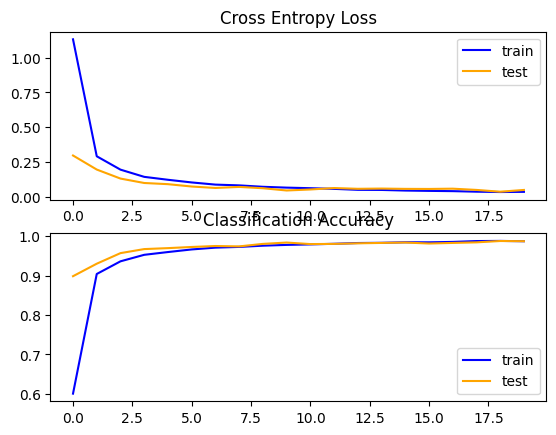

In [70]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_1.history['loss'], color='blue', label='train')
plt.plot(history_1.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_1.history['accuracy'], color='blue', label='train')
plt.plot(history_1.history['val_accuracy'], color='orange', label='test')
plt.legend()



###  Desempeño Modelo 2 CNN Simple

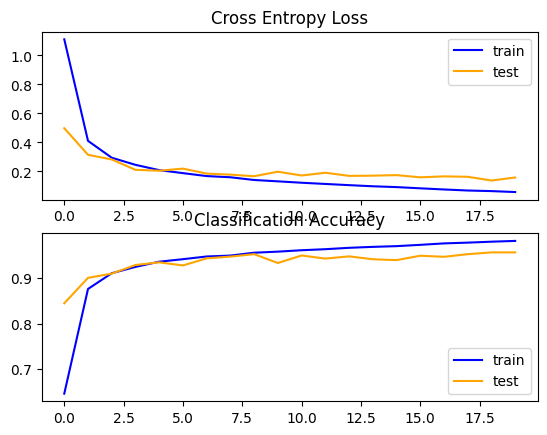

In [71]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_2.history['loss'], color='blue', label='train')
plt.plot(history_2.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_2.history['accuracy'], color='blue', label='train')
plt.plot(history_2.history['val_accuracy'], color='orange', label='test')
plt.legend()



### Desempeño Modelo 3 CNN con Dropout y Batch Normalization

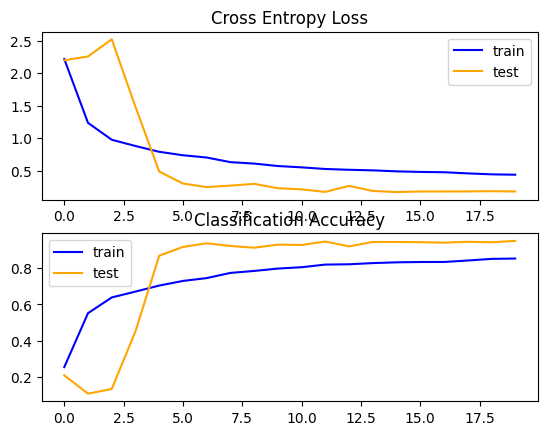

In [72]:
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_3.history['loss'], color='blue', label='train')
plt.plot(history_3.history['val_loss'], color='orange', label='test')
plt.legend()
 # plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_3.history['accuracy'], color='blue', label='train')
plt.plot(history_3.history['val_accuracy'], color='orange', label='test')
plt.legend()

